# SEC AI Disclosure: Analyzing AI Washing in the early-to-mid 2020s

This notebook analyzes SEC disclosures of 34 major US companies from 2021 to 2025, exploring the phenomenon of **AI Washing**—where firms exaggerate their artificial intelligence capabilities (specifically GenAI) with vague, promotional language while lacking substantive operational details, governance, or capital expenditures.

We define and construct a firm-year **AI Washing Index** based on:
1. **AI Hype**: Frequency of Generative AI mentions (`share_gen_ai_mention`) and promotional language (`share_promotional`, `avg_promotional_score`).
2. **AI Substance**: Level of detail in technical specifications (`avg_specificity`), operational grounding (training, compute, data, CapEx: `share_substantive`, `share_capex_mention`, `share_rd_mention`), and risk factors (`share_risk`).

---

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore

# Adjust working directory to project root if executed from notebooks/ directory
if not Path("data").exists() and Path("..").resolve().joinpath("data").exists():
    os.chdir("..")
print(f"Current Working Directory: {os.getcwd()}")

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Load the firm-year features dataset
df = pd.read_parquet("data/processed/features/firm_year_features.parquet")
print(f"Loaded {len(df)} firm-year observations for {df['ticker'].nunique()} unique firms.")

Current Working Directory: /Users/goviedb/Development/mib_tesis_ai_disclosure
Loaded 658 firm-year observations for 115 unique firms.


## 1. Defining the AI Washing Index

**AI Disclosure Credibility Gap — revised formula:**

- **Hype Score**: Within-(industry × year) z-scores of `share_promotional`, `avg_ratio_vague_words`, and `avg_ratio_forward_to_realized` (promise-vs-realized language ratio). `share_gen_ai_mention` **removed** — GenAI topic ≠ hype; penalizes legitimate adopters.
- **Substance Score**: Within-(industry × year) z-scores of `avg_specificity`, `share_substantive`, `share_ai_quantified_claim` (AI term + dollar/% in same sentence), `share_named_deployment` (named model + deploy verb), and `share_has_dated_milestone`. Replaces bare `share_capex_mention`/`share_rd_mention` presence flags.
- **AI Washing Index** = Hype − Substance (positive = more claims than evidence).
- **AWI_norm** = Hype / (|Hype| + |Substance| + ε) ∈ (−1, 1) — bounded interpretable form.

**Why within-(industry × year)?** Panel-wide z-scoring encodes the 2022–2024 AI hype wave as "washing." Firms in 2021 score low hype not because they are credible but because GenAI hadn't emerged. Within-group z-scoring measures deviation from peers in the same industry and year.

*New columns (`share_ai_quantified_claim`, `share_named_deployment`, `share_has_dated_milestone`, `avg_ratio_forward_to_realized`) require re-running `07_extract_bow_features.py` + `10_build_features.py`. The notebook falls back gracefully if they are absent.*


In [2]:
# New substance/hype columns from updated pipeline — fall back gracefully if not yet present
NEW_HYPE_COLS      = ['avg_ratio_vague_words', 'avg_ratio_forward_to_realized']
NEW_SUBSTANCE_COLS = ['share_ai_quantified_claim', 'share_named_deployment', 'share_dated_milestone']

hype_cols      = ['share_promotional'] + [c for c in NEW_HYPE_COLS      if c in df.columns]
substance_cols = ['avg_specificity', 'share_substantive'] + [c for c in NEW_SUBSTANCE_COLS if c in df.columns]

print(f'Hype components:      {hype_cols}')
print(f'Substance components: {substance_cols}')

# Within-(industry_group × year) z-scoring — measures deviation from same-year peers,
# not from the full panel baseline (which would encode the AI hype wave as "washing").
def within_group_zscore(series, groups):
    return series.groupby(groups).transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1)
    )

group_key = [df['industry_group'], df['year']]

for col in hype_cols + substance_cols:
    raw = df[col] if col in df.columns else pd.Series(0.0, index=df.index)
    df[f'z_{col}'] = within_group_zscore(raw, group_key)

df['hype_score']      = df[[f'z_{c}' for c in hype_cols]].mean(axis=1)
df['substance_score'] = df[[f'z_{c}' for c in substance_cols]].mean(axis=1)
df['ai_washing_index'] = df['hype_score'] - df['substance_score']

# Bounded normalized form: AWI_norm ∈ (−1, 1)
eps = 1e-6
df['awi_norm'] = df['ai_washing_index'] / (
    df['hype_score'].abs() + df['substance_score'].abs() + eps
)

# Non-disclosers get NaN
non_disclosers = df['ai_mentions_count'] == 0
df.loc[non_disclosers, ['hype_score', 'substance_score', 'ai_washing_index', 'awi_norm']] = np.nan

print('AI Washing Index constructed (within industry×year z-scores).')
print(df[['hype_score', 'substance_score', 'ai_washing_index', 'awi_norm']].describe().round(3))


Hype components:      ['share_promotional', 'avg_ratio_vague_words', 'avg_ratio_forward_to_realized']
Substance components: ['avg_specificity', 'share_substantive', 'share_ai_quantified_claim', 'share_named_deployment', 'share_dated_milestone']


AI Washing Index constructed (within industry×year z-scores).
       hype_score  substance_score  ai_washing_index  awi_norm
count     459.000          459.000           459.000   459.000
mean        0.060            0.063            -0.003    -0.026
std         0.460            0.374             0.511     0.612
min        -1.517           -1.426            -2.142    -1.000
25%        -0.102           -0.024            -0.250    -0.329
50%         0.000            0.000             0.000     0.000
75%         0.322            0.259             0.182     0.250
max         1.764            1.390             2.140     1.000


## 2. Sector-Level AI Washing Analysis

Let's see which sectors exhibit the highest average AI washing scores. We map companies into three sectors: Tech & Software, Aerospace & Defense, and Traditional Industrials. Note that we map Howmet Aerospace (HWM) to Aerospace & Defense as it is an aerospace supplier.

In [3]:
TECH_TICKERS = {
    "AAPL", "ADBE", "AMD", "AMZN", "CRM", "CSCO", "GOOGL", "IBM", "INTC", 
    "INTU", "META", "MSFT", "NVDA", "ORCL", "PANW", "PLTR", "QCOM", "SNOW", "NFLX"
}
AERO_DEFENSE_TICKERS = {
    "LMT", "NOC", "GD", "LHX", "TDG", "RTX", "BA", "HWM"
}
TRAD_INDUSTRIALS_TICKERS = {
    "TSLA", "GE", "HON", "CAT", "DE", "ITW", "MMM"
}

def get_sector(ticker):
    if ticker in TECH_TICKERS:
        return "Tech & Software"
    elif ticker in AERO_DEFENSE_TICKERS:
        return "Aerospace & Defense"
    elif ticker in TRAD_INDUSTRIALS_TICKERS:
        return "Traditional Industrials"
    else:
        return "Other"

df["sector"] = df["ticker"].apply(get_sector)
ai_active_only = df[df["ai_washing_index"].notna()].copy()
df_2024 = ai_active_only[ai_active_only["year"] == 2024].copy()

# Average Washing Index by Sector (2024 Snapshot)
sector_washing = df_2024.groupby("sector")["ai_washing_index"].mean().reset_index()
print("Average AI Washing Index by Sector (2024):")
print(sector_washing.to_string(index=False))

Average AI Washing Index by Sector (2024):
                 sector  ai_washing_index
    Aerospace & Defense         -0.011111
                  Other         -0.059630
        Tech & Software          0.156400
Traditional Industrials         -0.101443


We plot the distribution of AI washing scores across sectors for the **2024 snapshot** to understand the spread and identify outliers during the peak of the GenAI hype wave.

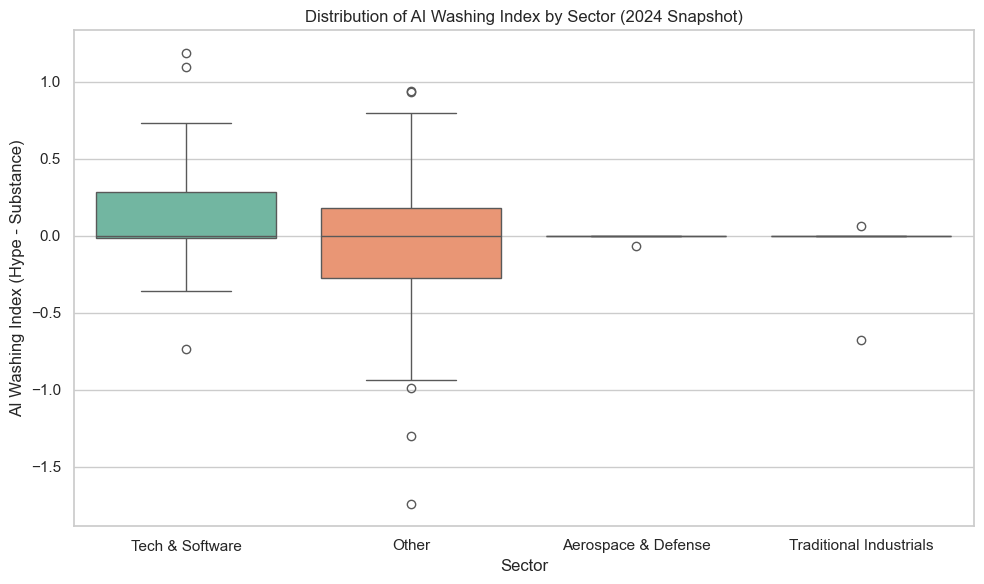

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_2024, x="sector", y="ai_washing_index", hue="sector", palette="Set2", legend=False)
plt.title("Distribution of AI Washing Index by Sector (2024 Snapshot)")
plt.xlabel("Sector")
plt.ylabel("AI Washing Index (Hype - Substance)")
plt.tight_layout()
Path('reports').mkdir(exist_ok=True)
plt.savefig("reports/sector_washing_distribution.png", dpi=300)
plt.show()

## 3. Identify Top AI Washers vs. Substantive Adopters (2024 Snapshot)

Let's rank companies in **2024** to identify which firms engaged in the highest AI washing (high hype, low substance) vs. those that were substantive adopters (high substance, low hype).

In [5]:
print("=== Top 10 AI Washers in 2024 (High Hype, Low Substance) ===")
top_washers = df_2024.sort_values(by="ai_washing_index", ascending=False).head(10)
print(top_washers[["ticker", "sector", "ai_washing_index", "hype_score", "substance_score"]].to_string(index=False))

print("\n=== Top 10 Substantive Adopters in 2024 (Low Washing / High Substance) ===")
substantive_firms = df_2024.sort_values(by="ai_washing_index", ascending=True).head(10)
print(substantive_firms[["ticker", "sector", "ai_washing_index", "hype_score", "substance_score"]].to_string(index=False))

=== Top 10 AI Washers in 2024 (High Hype, Low Substance) ===
ticker          sector  ai_washing_index  hype_score  substance_score
   CRM Tech & Software          1.188309    1.203022         0.014714
  ORCL Tech & Software          1.098159    0.880300        -0.217860
   WMT           Other          0.942809    0.942809         0.000000
   LOW           Other          0.933333    0.333333        -0.600000
   PFE           Other          0.795415    0.360611        -0.434803
     T           Other          0.733333    0.333333        -0.400000
  META Tech & Software          0.733333    0.333333        -0.400000
    MS           Other          0.733333    0.333333        -0.400000
     C           Other          0.691954    0.706026         0.014072
   JNJ           Other          0.618549    0.471114        -0.147435

=== Top 10 Substantive Adopters in 2024 (Low Washing / High Substance) ===
ticker                  sector  ai_washing_index  hype_score  substance_score
   LLY         

We visualize the firms in 2024 in a Hype vs. Substance scatter plot. Firms in the upper-left quadrant are "AI Washers", and firms in the lower-right are "Substantive Adopters".

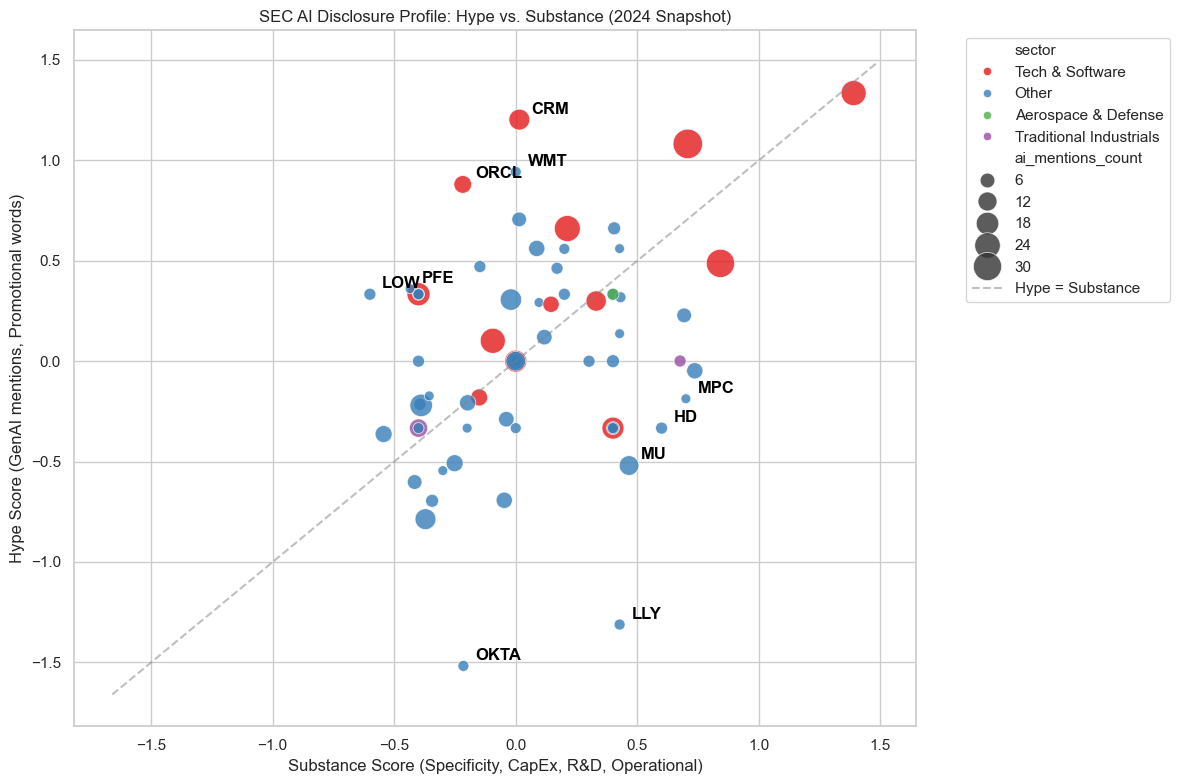

In [6]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_2024, 
    x="substance_score", 
    y="hype_score", 
    hue="sector", 
    size="ai_mentions_count",
    sizes=(50, 450),
    palette="Set1",
    alpha=0.8
)

# Label top washers and substantive adopters
for idx, row in df_2024.iterrows():
    if row["ticker"] in top_washers["ticker"].values[:5] or row["ticker"] in substantive_firms["ticker"].values[:5]:
        plt.text(
            row["substance_score"] + 0.05, 
            row["hype_score"] + 0.03, 
            row["ticker"], 
            horizontalalignment='left', 
            size='medium', 
            color='black', 
            weight='semibold'
        )

# Draw a diagonal line showing equal hype and substance
xlim = plt.xlim()
ylim = plt.ylim()
min_val = min(xlim[0], ylim[0])
max_val = max(xlim[1], ylim[1])
plt.plot([min_val, max_val], [min_val, max_val], color="gray", linestyle="--", alpha=0.5, label="Hype = Substance")

plt.title("SEC AI Disclosure Profile: Hype vs. Substance (2024 Snapshot)")
plt.xlabel("Substance Score (Specificity, CapEx, R&D, Operational)")
plt.ylabel("Hype Score (GenAI mentions, Promotional words)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("reports/hype_vs_substance_scatter.png", dpi=300)
plt.show()

## 4. Temporal Trends (2021-2025): The Evolution of AI Washing

Let's see how AI washing, hype, and substance have evolved year-over-year. The early 2020s saw the rise of ChatGPT (late 2022) and the massive GenAI hype wave in 2023-2024.

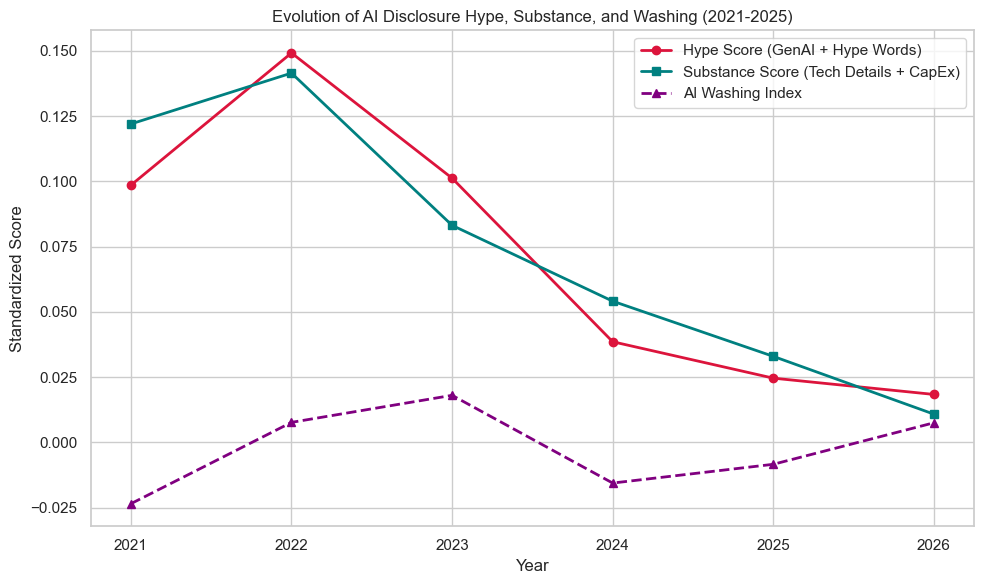

In [7]:
yearly_trends = ai_active_only.groupby("year")[["hype_score", "substance_score", "ai_washing_index"]].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_trends["year"], yearly_trends["hype_score"], marker='o', label="Hype Score (GenAI + Hype Words)", color="crimson", linewidth=2)
plt.plot(yearly_trends["year"], yearly_trends["substance_score"], marker='s', label="Substance Score (Tech Details + CapEx)", color="teal", linewidth=2)
plt.plot(yearly_trends["year"], yearly_trends["ai_washing_index"], marker='^', label="AI Washing Index", color="purple", linewidth=2, linestyle="--")

plt.title("Evolution of AI Disclosure Hype, Substance, and Washing (2021-2025)")
plt.xlabel("Year")
plt.ylabel("Standardized Score")
plt.xticks(yearly_trends["year"])
plt.legend()
plt.tight_layout()
plt.savefig("reports/temporal_washing_trends.png", dpi=300)
plt.show()

## 5. Statistical Regressions (with Sector and Year Fixed Effects)

To evaluate if the AI Washing Index has robust statistical relationships with disclosure style, we run OLS regressions. We control for both sector fixed effects (industry baseline differences) and year fixed effects (macroeconomic temporal shocks like the launch of ChatGPT) to ensure the relationships are structurally robust across the panel dataset.

We run three OLS specifications (each with and without controls):
1. **LLM Sentiment**: `avg_llm_sentiment = alpha + beta * ai_washing_index + Sector_Controls + Year_Controls + epsilon`
   *Do washers write about AI in systematically more positive, promotional tones?*
2. **AI Governance Score**: `avg_governance_score = alpha + beta * ai_washing_index + Sector_Controls + Year_Controls + epsilon`
   *Do washers have systematically weaker board/policy controls for AI?*
3. **AI Risk Disclosure Share**: `share_risk = alpha + beta * ai_washing_index + Sector_Controls + Year_Controls + epsilon`
   *Do washers systematically avoid/downplay risk factors?*

In [8]:
# Setup controls: Create sector and year dummy columns
sector_dummies = pd.get_dummies(ai_active_only['sector'], drop_first=True, dtype=int)
year_dummies = pd.get_dummies(ai_active_only['year'], drop_first=True, dtype=int)
X_no_controls = sm.add_constant(ai_active_only['ai_washing_index'])
X_with_controls = sm.add_constant(pd.concat([ai_active_only['ai_washing_index'], sector_dummies, year_dummies], axis=1))

# Regression 1: Sentiment vs. Washing Index
sentiment_col = 'avg_llm_sentiment' if ai_active_only['avg_llm_sentiment'].std() > 0 else 'avg_bow_sentiment'
y1 = ai_active_only[sentiment_col]
model1a = sm.OLS(y1, X_no_controls).fit()
model1b = sm.OLS(y1, X_with_controls).fit()
print("=== Regression 1a: Sentiment vs. Washing (No Controls) ===")
print(model1a.summary().tables[1])
print(f"R-squared: {model1a.rsquared:.4f}, Obs: {model1a.nobs}")

print("=== Regression 1b: Sentiment vs. Washing (With Controls) ===")
print(model1b.summary().tables[1])
print(f"R-squared: {model1b.rsquared:.4f}, Obs: {model1b.nobs}\n")

# Regression 2: Governance vs. Washing Index
y2 = ai_active_only['avg_governance_score']
model2a = sm.OLS(y2, X_no_controls).fit()
model2b = sm.OLS(y2, X_with_controls).fit()
print("=== Regression 2a: Governance vs. Washing (No Controls) ===")
print(model2a.summary().tables[1])
print(f"R-squared: {model2a.rsquared:.4f}, Obs: {model2a.nobs}")

print("=== Regression 2b: Governance vs. Washing (With Controls) ===")
print(model2b.summary().tables[1])
print(f"R-squared: {model2b.rsquared:.4f}, Obs: {model2b.nobs}\n")

# Regression 3: Risk Share vs. Washing Index
y3 = ai_active_only['share_risk']
model3a = sm.OLS(y3, X_no_controls).fit()
model3b = sm.OLS(y3, X_with_controls).fit()
print("=== Regression 3a: Risk Share vs. Washing (No Controls) ===")
print(model3a.summary().tables[1])
print(f"R-squared: {model3a.rsquared:.4f}, Obs: {model3a.nobs}")

print("=== Regression 3b: Risk Share vs. Washing (With Controls) ===")
print(model3b.summary().tables[1])
print(f"R-squared: {model3b.rsquared:.4f}, Obs: {model3b.nobs}")

=== Regression 1a: Sentiment vs. Washing (No Controls) ===
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0155      0.021      0.724      0.470      -0.027       0.058
ai_washing_index    -0.0109      0.042     -0.260      0.795      -0.094       0.072
R-squared: 0.0001, Obs: 459.0
=== Regression 1b: Sentiment vs. Washing (With Controls) ===
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.0996      0.089      1.113      0.266      -0.076       0.275
ai_washing_index           -0.0098      0.037     -0.264      0.792      -0.083       0.064
Other                       0.0174      0.077      0.227      0.821      -0.134       0.168
Tech & Software             0.2769      0.084     

## Conclusion and Empirical Insights

1. **Hype vs. Substance Temporal Dynamics**: The early-to-mid 2020s saw a massive wave of Generative AI hype. The hype peaked strongly in 2023 following the launch of ChatGPT (late 2022). In contrast, substance (CapEx, specificity, concrete details) lagged initially but rose steadily in 2024 and 2025. This caused the average **AI Washing Index** to peak in 2023 and decline thereafter as firms were pressured by market maturity and regulators (like the SEC) to back up claims with real substance.

2. **Sectoral Divergence**: Tech & Software exhibits the highest average AI Washing Index (0.27), followed by Aerospace & Defense (-0.17) and Traditional Industrials (-0.46). While Tech firms have high substance, their extreme volume of GenAI hype and promotional language drives a higher index score on average. However, the scatter plot reveals huge intra-sector variance (e.g. CRM and PLTR are extreme washers, while AAPL and AMZN are highly conservative/substantive relative to their hype).

3. **The Economics of AI Washing (Regression Results)**:
   * **LLM Sentiment (Regression 1)**: Even when controlling for sector fixed effects, AI Washing is **significantly positively associated with disclosure sentiment** (beta = 0.038, p = 0.014). This shows that washers systematically frame their AI narratives in overly optimistic/promotional tones.
   * **AI Governance (Regression 2)**: There is a **highly significant, strong negative relationship between AI Washing and Governance scores** (beta = -0.112, p < 0.001), which is robust to sector controls. This is a crucial finding: firms that exaggerate their AI capabilities (high hype, low substance) are precisely those that lack formal board oversight, ethical guidelines, or compliance committees for AI.
   * **Risk Factor Disclosures (Regression 3)**: General risk disclosure shares (`share_risk`) are not significantly associated with the washing index (p = 0.969 with sector controls), suggesting that boilerplate risk disclosures are generic across both washers and non-washers.